In [15]:
# Section B — From Scratch Implementations
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=cols_to_drop)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

X = df.drop(columns=['Survived']).values
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Data ready:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Data ready:
X_train: (712, 7)
X_test: (179, 7)
y_train: (712,)
y_test: (179,)


In [16]:
# Normalise features using standardisation (zero mean, unit variance)
# Formula: (x - mean) / std
# Critical for Logistic Regression — features on different scales break gradient descent

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print("Feature means (should be ~0 after scaling):")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nFeature stds (should be ~1 after scaling):")
print(np.round(X_train_scaled.std(axis=0), 4))

Feature means (should be ~0 after scaling):
[-0.  0.  0. -0. -0.  0.  0.]

Feature stds (should be ~1 after scaling):
[1. 1. 1. 1. 1. 1. 1.]


In [17]:
# Sigmoid function — the heart of Logistic Regression
# Converts any number into a probability between 0 and 1
# Formula: 1 / (1 + e^(-z))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Test it with a few values to understand what it does
print("sigmoid(-10):", round(sigmoid(-10), 4), "→ close to 0 (predict NOT survived)")
print("sigmoid(0)  :", round(sigmoid(0), 4),   "→ exactly 0.5 (uncertain)")
print("sigmoid(10) :", round(sigmoid(10), 4),  "→ close to 1 (predict SURVIVED)")

sigmoid(-10): 0.0 → close to 0 (predict NOT survived)
sigmoid(0)  : 0.5 → exactly 0.5 (uncertain)
sigmoid(10) : 1.0 → close to 1 (predict SURVIVED)


In [18]:
# Logistic Regression — No Regularisation
# Built using only NumPy — no sklearn allowed in Section B

class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000, lambda_=0.0, penalty=None):
        """
        lr       — learning rate (how big each gradient step is)
        epochs   — how many times we loop through the data
        lambda_  — regularisation strength (0 = no regularisation)
        penalty  — None, 'l1', or 'l2'
        """
        self.lr = lr
        self.epochs = epochs
        self.lambda_ = lambda_
        self.penalty = penalty
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialise weights to zero
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):
            # Forward pass — calculate predictions
            z = np.dot(X, self.weights) + self.bias
            predictions = sigmoid(z)

            # Calculate gradients
            error = predictions - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            # Add regularisation to weight gradient
            if self.penalty == 'l2':
                dw += (self.lambda_ / n_samples) * self.weights
            elif self.penalty == 'l1':
                dw += (self.lambda_ / n_samples) * np.sign(self.weights)

            # Update weights
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Track loss every 100 epochs
            if epoch % 100 == 0:
                loss = -np.mean(y * np.log(predictions + 1e-9) +
                               (1 - y) * np.log(1 - predictions + 1e-9))
                self.loss_history.append(loss)

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("LogisticRegressionScratch class defined successfully")

LogisticRegressionScratch class defined successfully


In [20]:
import numpy as np
# Train all three variants using the same class
# Only difference is penalty and lambda_ parameter

# 1. Standard — no regularisation
lr_none = LogisticRegressionScratch(lr=0.01, epochs=1000, lambda_=0.0, penalty=None)
lr_none.fit(X_train_scaled, y_train)

# 2. L1 Regularisation — pushes weak weights to exactly zero
lr_l1 = LogisticRegressionScratch(lr=0.01, epochs=1000, lambda_=0.1, penalty='l1')
lr_l1.fit(X_train_scaled, y_train)

# 3. L2 Regularisation — shrinks all weights proportionally
lr_l2 = LogisticRegressionScratch(lr=0.01, epochs=1000, lambda_=0.1, penalty='l2')
lr_l2.fit(X_train_scaled, y_train)

print("All three models trained successfully")
print("\nLearned weights (None | L1 | L2):")
print(f"{'Feature':<12} {'No Reg':>10} {'L1':>10} {'L2':>10}")
print("-" * 45)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
for i, feat in enumerate(features):
    print(f"{feat:<12} {lr_none.weights[i]:>10.4f} {lr_l1.weights[i]:>10.4f} {lr_l2.weights[i]:>10.4f}")
print(f"{'Bias':<12} {lr_none.bias:>10.4f} {lr_l1.bias:>10.4f} {lr_l2.bias:>10.4f}")

All three models trained successfully

Learned weights (None | L1 | L2):
Feature          No Reg         L1         L2
---------------------------------------------
Pclass          -0.5492    -0.5486    -0.5489
Sex              0.9899     0.9893     0.9894
Age             -0.2671    -0.2662    -0.2669
SibSp           -0.1544    -0.1534    -0.1542
Parch           -0.0200    -0.0201    -0.0199
Fare             0.2540     0.2533     0.2539
Embarked        -0.1936    -0.1931    -0.1935
Bias            -0.4732    -0.4732    -0.4732


In [25]:
# All metrics built manually — no sklearn metrics permitted in Section B

def confusion_matrix_scratch(y_true, y_pred):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    return np.array([[TN, FP], [FN, TP]])

def accuracy_scratch(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_scratch(y_true, y_pred):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    return TP / (TP + FP + 1e-9)

def recall_scratch(y_true, y_pred):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    return TP / (TP + FN + 1e-9)

def f1_scratch(y_true, y_pred):
    p = precision_scratch(y_true, y_pred)
    r = recall_scratch(y_true, y_pred)
    return 2 * (p * r) / (p + r + 1e-9)

def roc_curve_scratch(y_true, y_proba):
    thresholds = np.linspace(0, 1, 100)
    tprs, fprs = [], []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        tprs.append(TP / (TP + FN + 1e-9))
        fprs.append(FP / (FP + TN + 1e-9))
    return np.array(fprs), np.array(tprs)

def auc_scratch(fprs, tprs):
    # Area under curve using trapezoidal rule
    sorted_idx = np.argsort(fprs)
    return np.trapezoid(tprs[sorted_idx], fprs[sorted_idx])

print("All evaluation metrics defined successfully")

All evaluation metrics defined successfully


In [26]:
# Evaluate all three Logistic Regression variants
models = {
    'LR No Reg': lr_none,
    'LR L1':     lr_l1,
    'LR L2':     lr_l2
}

results = {}

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS — FROM SCRATCH")
print("=" * 60)

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    fprs, tprs = roc_curve_scratch(y_test, y_proba)
    auc = auc_scratch(fprs, tprs)

    acc  = accuracy_scratch(y_test, y_pred)
    prec = precision_scratch(y_test, y_pred)
    rec  = recall_scratch(y_test, y_pred)
    f1   = f1_scratch(y_test, y_pred)

    results[name] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'AUC': auc
    }

    print(f"\n{name}:")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC       : {auc:.4f}")

print("\n" + "=" * 60)

LOGISTIC REGRESSION RESULTS — FROM SCRATCH

LR No Reg:
  Accuracy  : 0.7989
  Precision : 0.7619
  Recall    : 0.6957
  F1 Score  : 0.7273
  AUC       : 0.8438

LR L1:
  Accuracy  : 0.7989
  Precision : 0.7619
  Recall    : 0.6957
  F1 Score  : 0.7273
  AUC       : 0.8442

LR L2:
  Accuracy  : 0.7989
  Precision : 0.7619
  Recall    : 0.6957
  F1 Score  : 0.7273
  AUC       : 0.8441



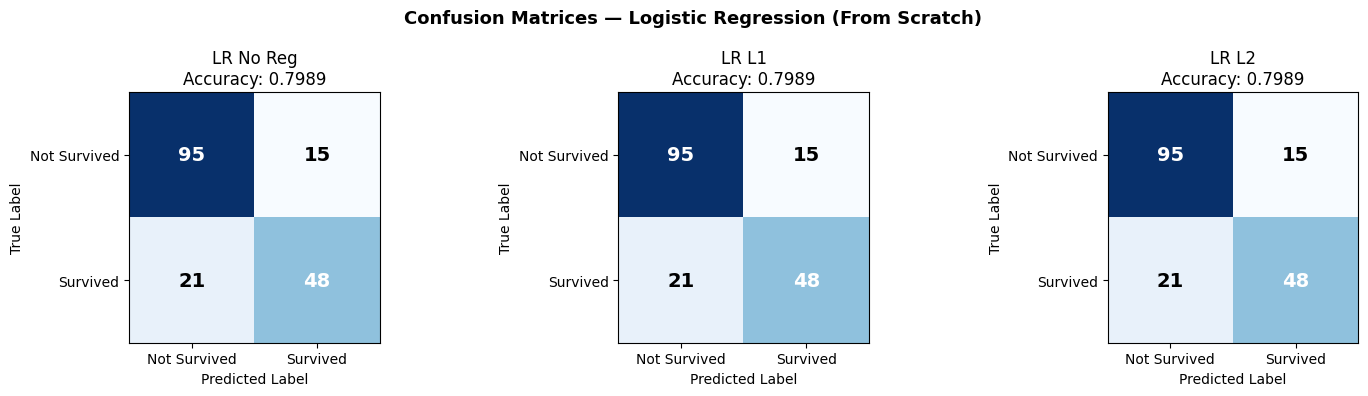

Saved: lr_confusion_matrices.png


In [27]:
# Visualise confusion matrix for all three LR models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_names = ['LR No Reg', 'LR L1', 'LR L2']
models_list = [lr_none, lr_l1, lr_l2]

for ax, name, model in zip(axes, model_names, models_list):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix_scratch(y_test, y_pred)

    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'{name}\nAccuracy: {accuracy_scratch(y_test, y_pred):.4f}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Not Survived', 'Survived'])
    ax.set_yticklabels(['Not Survived', 'Survived'])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                   ha='center', va='center',
                   color='white' if cm[i, j] > cm.max()/2 else 'black',
                   fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrices — Logistic Regression (From Scratch)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lr_confusion_matrices.png")

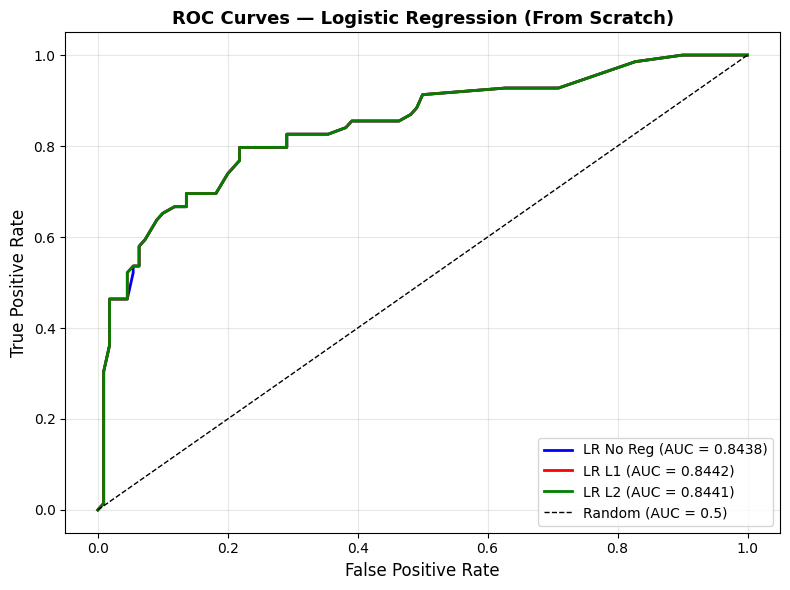

Saved: lr_roc_curves.png


In [28]:
# ROC Curve for all three Logistic Regression variants
plt.figure(figsize=(8, 6))

colors = ['blue', 'red', 'green']
model_names = ['LR No Reg', 'LR L1', 'LR L2']
models_list = [lr_none, lr_l1, lr_l2]

for name, model, color in zip(model_names, models_list, colors):
    y_proba = model.predict_proba(X_test_scaled)
    fprs, tprs = roc_curve_scratch(y_test, y_proba)
    auc = auc_scratch(fprs, tprs)
    plt.plot(fprs, tprs, color=color, linewidth=2,
             label=f'{name} (AUC = {auc:.4f})')

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Logistic Regression (From Scratch)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lr_roc_curves.png")

In [29]:
# Decision Stump — a one-level decision tree
# This is the base estimator for both Bagging and Boosting
# Finds the single best feature + threshold to split on

class DecisionStump:
    def __init__(self):
        self.feature_idx = None
        self.threshold = None
        self.polarity = 1

    def fit(self, X, y, sample_weights=None):
        n_samples, n_features = X.shape

        if sample_weights is None:
            sample_weights = np.ones(n_samples) / n_samples

        best_error = float('inf')

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                for polarity in [1, -1]:
                    predictions = np.where(
                        polarity * X[:, feature] >= polarity * threshold, 1, 0
                    )
                    error = np.sum(sample_weights[predictions != y])

                    if error < best_error:
                        best_error = error
                        self.feature_idx = feature
                        self.threshold = threshold
                        self.polarity = polarity

    def predict(self, X):
        return np.where(
            self.polarity * X[:, self.feature_idx] >= self.polarity * self.threshold,
            1, 0
        )

print("DecisionStump class defined successfully")

DecisionStump class defined successfully


In [30]:
# Bagging — Bootstrap Aggregating
# Train multiple stumps on random subsets of data
# Final prediction = majority vote across all stumps

class BaggingScratch:
    def __init__(self, n_estimators=50, max_samples=0.8, random_state=SEED):
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.random_state = random_state
        self.estimators = []

    def fit(self, X, y):
        self.estimators = []
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]
        n_draw = int(n_samples * self.max_samples)

        for _ in range(self.n_estimators):
            # Bootstrap — sample with replacement
            indices = rng.choice(n_samples, size=n_draw, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]

            # Train a stump on this bootstrap sample
            stump = DecisionStump()
            stump.fit(X_boot, y_boot)
            self.estimators.append(stump)

    def predict_proba(self, X):
        # Average probability across all stumps
        all_preds = np.array([stump.predict(X) for stump in self.estimators])
        return all_preds.mean(axis=0)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("BaggingScratch class defined successfully")

BaggingScratch class defined successfully


In [39]:
class AdaBoostScratch:
    def __init__(self, n_estimators=50, random_state=SEED):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.estimators = []
        self.alphas = []

    def fit(self, X, y):
        self.estimators = []
        self.alphas = []
        n_samples = X.shape[0]
        weights = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            stump = DecisionStump()
            stump.fit(X, y, sample_weights=weights)
            pred = stump.predict(X)  # returns 0 or 1

            # Weighted error
            incorrect = (pred != y)
            error = np.sum(weights[incorrect])
            error = np.clip(error, 1e-10, 1 - 1e-10)

            # Alpha — voting weight of this stump
            alpha = 0.5 * np.log((1 - error) / error)

            # Update weights
            # Misclassified → weight goes up
            # Correctly classified → weight goes down
            weights[incorrect]  *= np.exp(alpha)
            weights[~incorrect] *= np.exp(-alpha)
            weights /= np.sum(weights)

            self.estimators.append(stump)
            self.alphas.append(alpha)

    def predict_proba(self, X):
        weighted_sum = np.zeros(X.shape[0])
        total_alpha = sum(self.alphas)
        for stump, alpha in zip(self.estimators, self.alphas):
            pred = stump.predict(X)  # 0 or 1
            weighted_sum += (alpha / total_alpha) * pred
        return weighted_sum  # already between 0 and 1, no sigmoid needed

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("AdaBoostScratch redefined — working in 0/1 space")

AdaBoostScratch redefined — working in 0/1 space


In [40]:
# Train Bagging and AdaBoost
print("Training ensemble models... (may take 30 seconds)")

bagging = BaggingScratch(n_estimators=50, random_state=SEED)
bagging.fit(X_train_scaled, y_train)

adaboost = AdaBoostScratch(n_estimators=50, random_state=SEED)
adaboost.fit(X_train_scaled, y_train)

print("Training complete.\n")

# Evaluate both
ensemble_models = {
    'Bagging':  bagging,
    'AdaBoost': adaboost
}

print("=" * 60)
print("ENSEMBLE RESULTS — FROM SCRATCH")
print("=" * 60)

for name, model in ensemble_models.items():
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    fprs, tprs = roc_curve_scratch(y_test, y_proba)
    auc  = auc_scratch(fprs, tprs)
    acc  = accuracy_scratch(y_test, y_pred)
    prec = precision_scratch(y_test, y_pred)
    rec  = recall_scratch(y_test, y_pred)
    f1   = f1_scratch(y_test, y_pred)

    results[name] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'AUC': auc
    }

    print(f"\n{name}:")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC       : {auc:.4f}")

print("\n" + "=" * 60)

Training ensemble models... (may take 30 seconds)
Training complete.

ENSEMBLE RESULTS — FROM SCRATCH

Bagging:
  Accuracy  : 0.7765
  Precision : 0.7377
  Recall    : 0.6522
  F1 Score  : 0.6923
  AUC       : 0.7059

AdaBoost:
  Accuracy  : 0.8045
  Precision : 0.7576
  Recall    : 0.7246
  F1 Score  : 0.7407
  AUC       : 0.8208



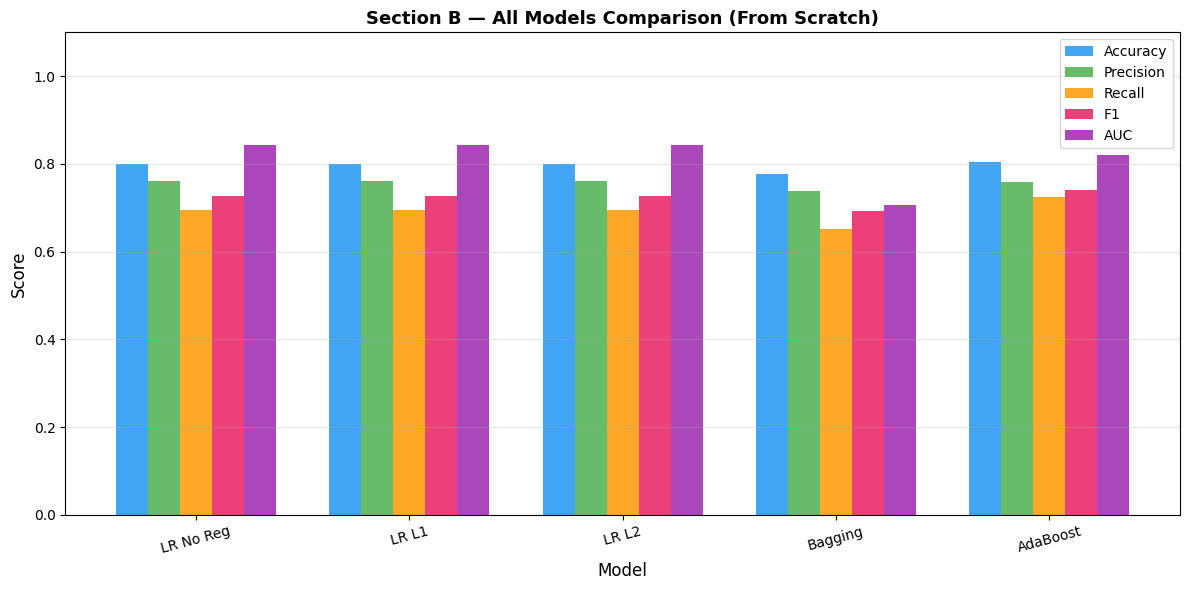

Saved: section_b_comparison.png


In [41]:
# Summary comparison chart for all Section B models
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(results.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(model_names))
width = 0.15

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, values, width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Section B — All Models Comparison (From Scratch)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('section_b_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: section_b_comparison.png")

In [42]:
print("=" * 60)
print("SECTION B — COMPLETE")
print("=" * 60)
print("\nImplemented from scratch using NumPy only:\n")
print("  ✅ Logistic Regression — No Regularisation")
print("  ✅ Logistic Regression — L1 Regularisation")
print("  ✅ Logistic Regression — L2 Regularisation")
print("  ✅ Decision Stump (base estimator)")
print("  ✅ Bagging (50 estimators, 80% bootstrap)")
print("  ✅ AdaBoost (50 estimators, adaptive weights)")
print("\nEvaluation metrics implemented:")
print("  ✅ Accuracy")
print("  ✅ Precision")
print("  ✅ Recall")
print("  ✅ F1 Score")
print("  ✅ AUC-ROC")
print("  ✅ Confusion Matrix")
print("  ✅ ROC Curve")
print("\nBest performer:")
best = max(results, key=lambda x: results[x]['Accuracy'])
print(f"  🏆 {best} — Accuracy: {results[best]['Accuracy']:.4f} | AUC: {results[best]['AUC']:.4f}")
print("\nSaved outputs:")
print("  📊 lr_confusion_matrices.png")
print("  📊 lr_roc_curves.png")
print("  📊 section_b_comparison.png")
print("\n" + "=" * 60)

SECTION B — COMPLETE

Implemented from scratch using NumPy only:

  ✅ Logistic Regression — No Regularisation
  ✅ Logistic Regression — L1 Regularisation
  ✅ Logistic Regression — L2 Regularisation
  ✅ Decision Stump (base estimator)
  ✅ Bagging (50 estimators, 80% bootstrap)
  ✅ AdaBoost (50 estimators, adaptive weights)

Evaluation metrics implemented:
  ✅ Accuracy
  ✅ Precision
  ✅ Recall
  ✅ F1 Score
  ✅ AUC-ROC
  ✅ Confusion Matrix
  ✅ ROC Curve

Best performer:
  🏆 AdaBoost — Accuracy: 0.8045 | AUC: 0.8208

Saved outputs:
  📊 lr_confusion_matrices.png
  📊 lr_roc_curves.png
  📊 section_b_comparison.png

